# Dataset description
## Deaths by Age Group
**Source**: DANE

**Download**: [DANE](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

# Code
## Imports

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import re

## Load data

In [102]:
path = "./data/area_grupo_edad.csv"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,2])

## Clean data

In [103]:
only_years = df[df["grupo_edad"].str.contains("año")]
def get_start_age(age_str):
    numbers = re.findall(r"\d+", age_str)
    return int(numbers[0]) if numbers else 0

only_years = only_years.copy()
only_years["edad_inicio"] = only_years["grupo_edad"].apply(get_start_age)

# Filter by age ranges
df_1_19 = only_years[only_years["edad_inicio"].between(1, 19)].groupby("Fecha")["total"].sum().reset_index()
df_20_39 = only_years[only_years["edad_inicio"].between(20, 39)].groupby("Fecha")["total"].sum().reset_index()

# Normalize data (0 to 1)
df_1_19["total"] = (df_1_19["total"] - df_1_19["total"].min()) / (df_1_19["total"].max() - df_1_19["total"].min())
df_20_39["total"] = (df_20_39["total"] - df_20_39["total"].min()) / (df_20_39["total"].max() - df_20_39["total"].min())

## Plot

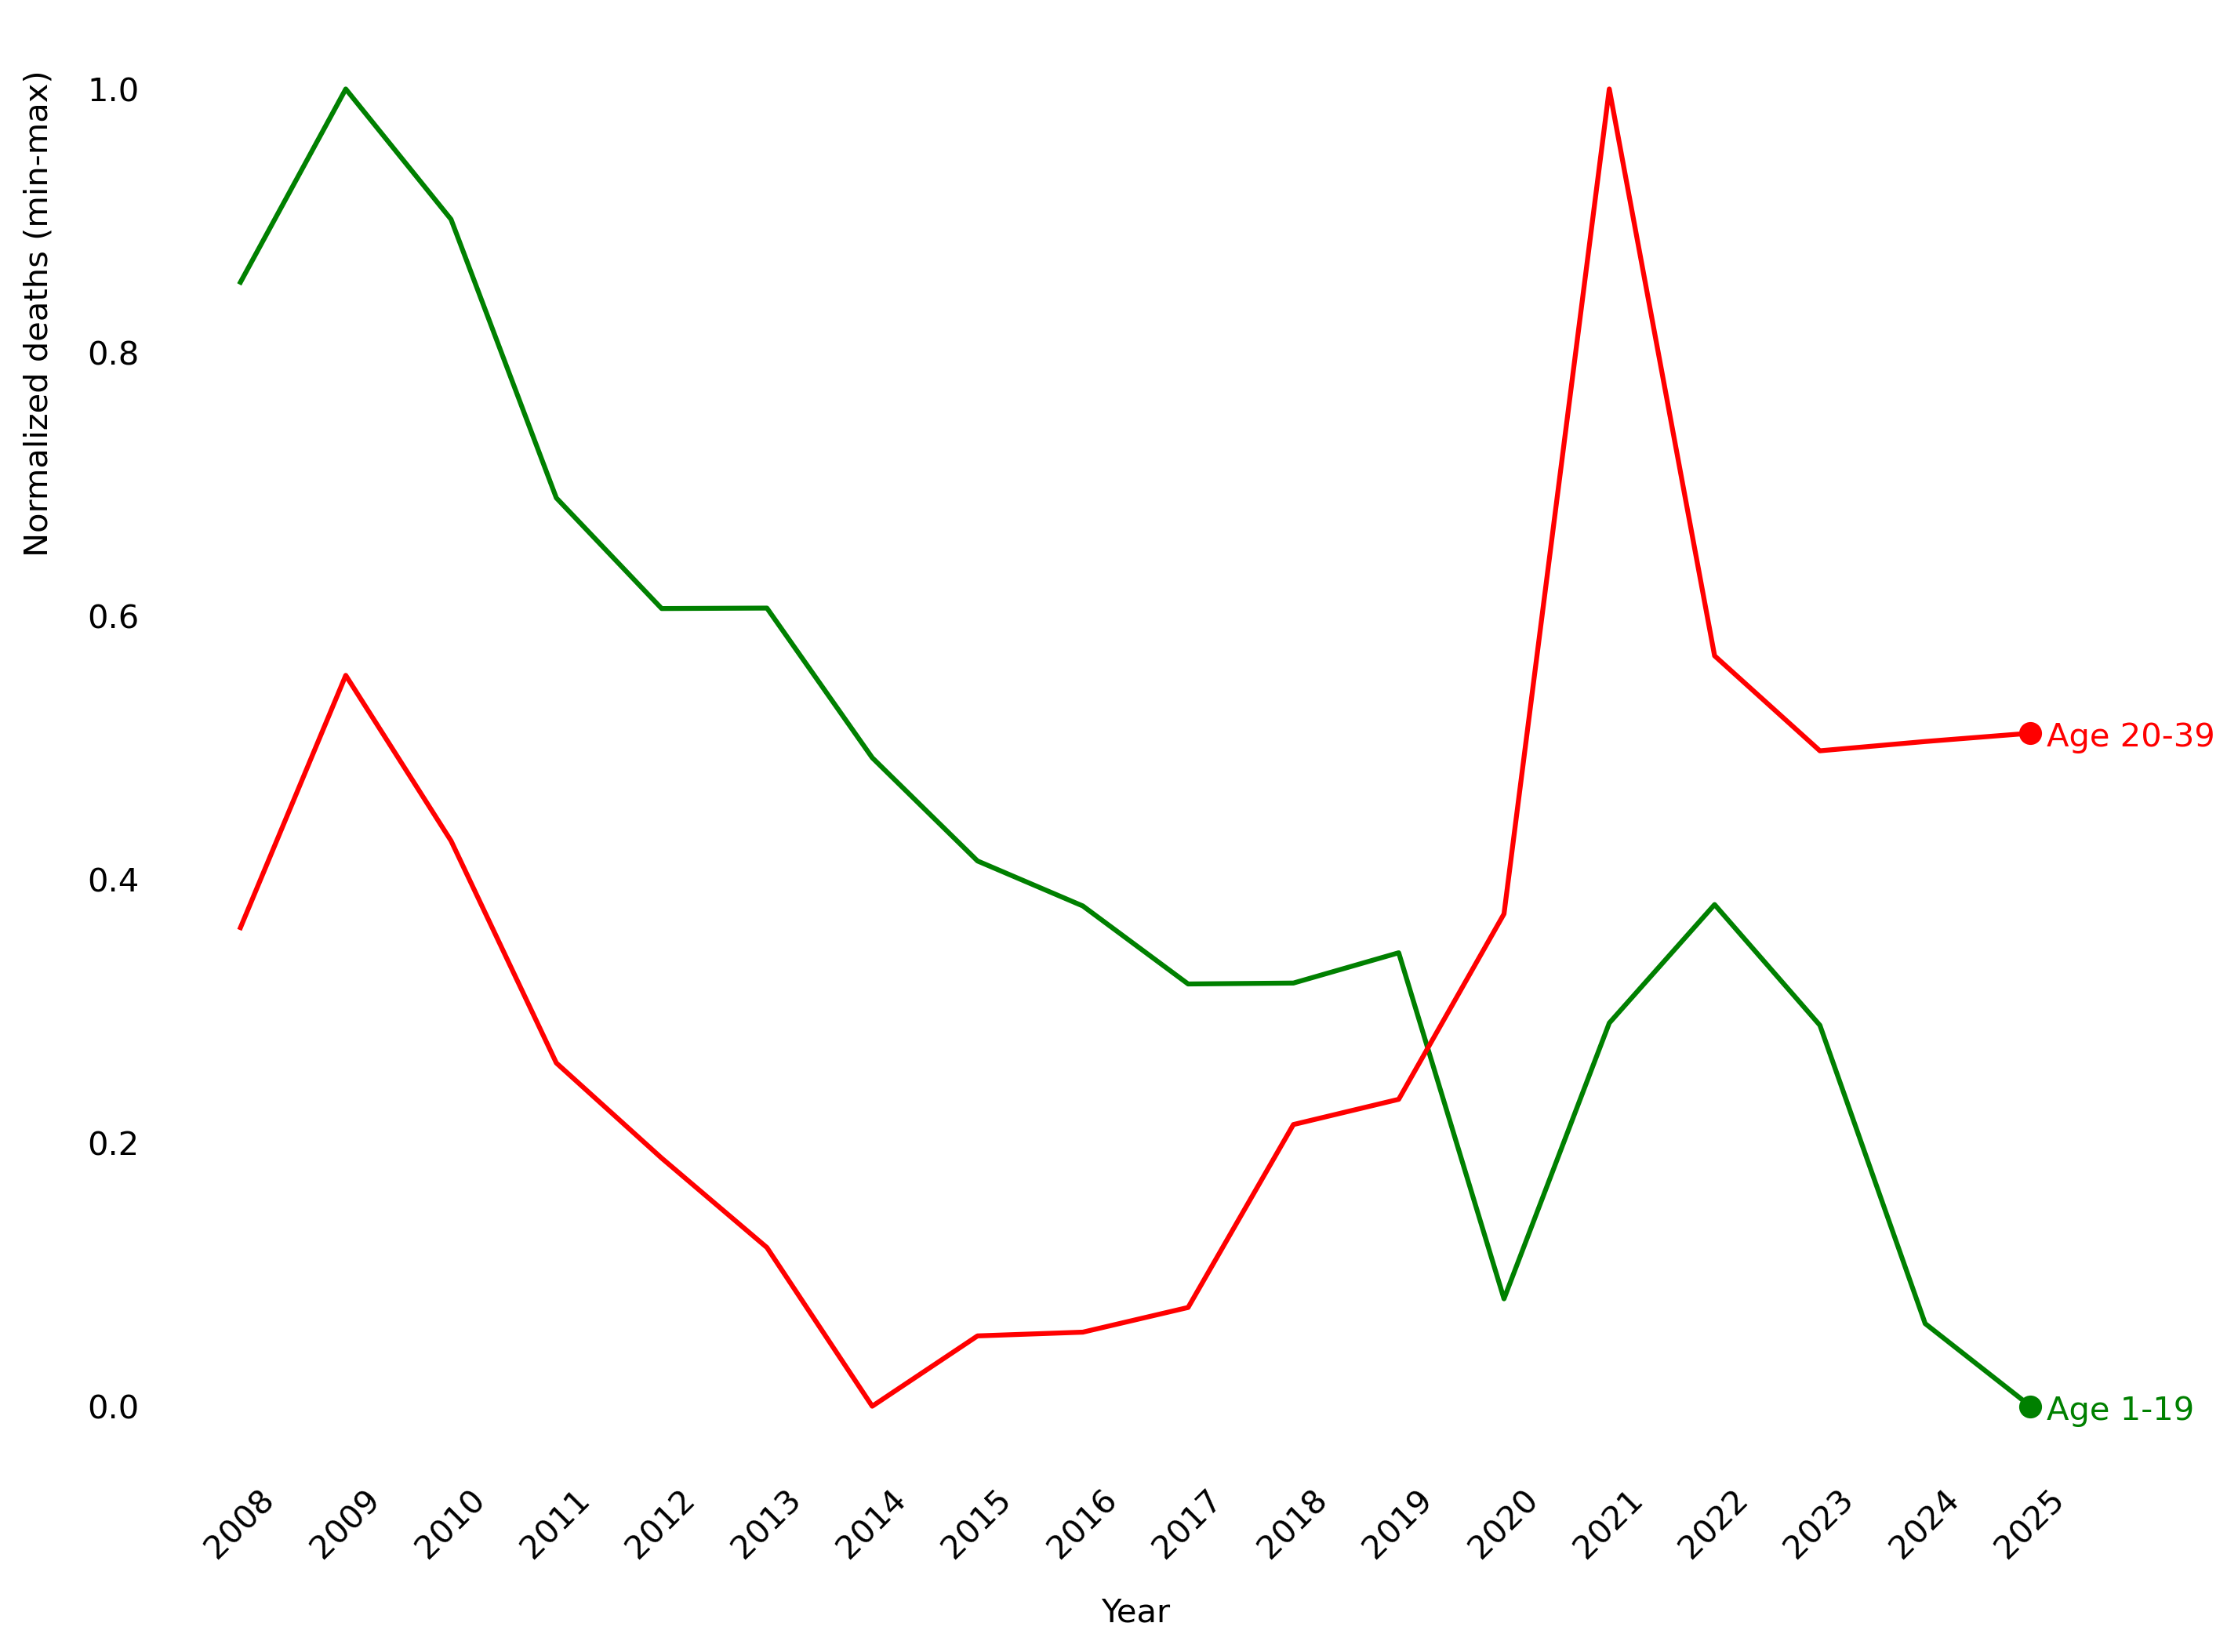

In [104]:
plt.figure(figsize=(10.8, 8), dpi=300)

plt.plot(df_1_19["Fecha"], df_1_19["total"], color="green")
plt.text(df_1_19["Fecha"].values[-1] + 0.15, df_1_19["total"].values[-1] - 0.01, "Age 1-19", color="green")
plt.scatter(df_1_19["Fecha"].values[-1], df_1_19["total"].values[-1], color="green")

plt.plot(df_20_39["Fecha"], df_20_39["total"], color="red")
plt.text(df_20_39["Fecha"].values[-1] + 0.15, df_20_39["total"].values[-1] - 0.01, "Age 20-39", color="red")
plt.scatter(df_20_39["Fecha"].values[-1], df_20_39["total"].values[-1], color="red")


plt.xticks(df_1_19["Fecha"], rotation=45)

for side in ["top", "left", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.xlabel("Year", labelpad=10, fontsize=10)
plt.ylabel("Normalized deaths (min-max)", labelpad=10, fontsize=10, y=0.8)

plt.show()